# EOS PDF, Curves and Constraints

[171.33657061262716, 3.7790377427582174]
[171.33657061262716, 2.0832375804296883]


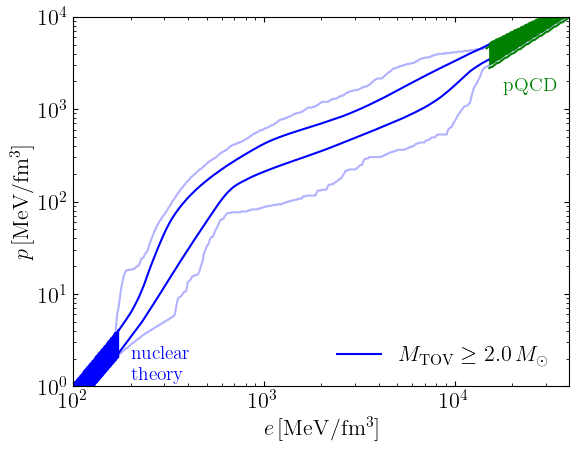

In [1]:
import numpy as np
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib import ticker
from scipy.optimize import curve_fit
from pylab import *
from scipy import ndimage
from matplotlib.colors import LinearSegmentedColormap
from functools import reduce
import operator

# LaTeX font
plt.rcParams.update({
    "text.usetex": True,
    'font.size': 16
    })

# plot file
plname="EOS.pdf"

# CET eos
CET=np.loadtxt("CET.txt")

# pQCD band
pQCD=np.loadtxt("pQCD.txt")

# outer contours
constraint1=np.loadtxt("cloudEOS2p0.txt")
constraint2=np.loadtxt("cloudEOS2p18.txt")
constraint3=np.loadtxt("cloudEOS2p35.txt")
constraint4=np.loadtxt("cloudEOS2p52.txt")

# 90% contours
cont1=np.loadtxt("cont0p1peMtov2p0.dat")
cont2=np.loadtxt("cont0p1peMtov2p18.dat")
cont3=np.loadtxt("cont0p1peMtov2p35.dat")
cont4=np.loadtxt("cont0p1peMtov2p52.dat")


# generating a figure
fig, ax=plt.subplots(sharex=True,facecolor='white',dpi=100)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim([100,4*10**4])
ax.set_ylim([1,10**4])
#ax.grid(color="gray", linestyle="dashed", linewidth=0.5)
ax.tick_params(which='major', direction='in',top="true",right="true")
ax.tick_params(which='minor', direction='in',top="true",right="true")
plt.xlabel(r'$e\,\rm [MeV/fm^3]$', fontsize = 16)
plt.ylabel(r'$p\,\rm [MeV/fm^3]$',fontsize =  16)

# outer contours
# Mtov>2.0Msun
plt.plot(10**constraint1[:,0],10**constraint1[:,1], color = "blue"  , linestyle = "solid",zorder=1, alpha=0.3)
plt.plot(10**constraint1[:,2],10**constraint1[:,3], color = "blue"  , linestyle = "solid",zorder=1, alpha=0.3)
plt.plot(10**cont1[:,0],10**cont1[:,1],             color = "blue"  , linestyle = "solid",zorder=1)
plt.plot(10**cont1[:,0],10**cont1[:,2],             color = "blue"  , linestyle = "solid",zorder=1,label=r"$M_{\rm TOV}\geq 2.0\,M_\odot$")

# Mtov>2.18Msun
# plt.plot(10**constraint2[:,0],10**constraint2[:,1], color = "black", linestyle = "solid",zorder=1, alpha=0.8)
# plt.plot(10**constraint2[:,2],10**constraint2[:,3], color = "black", linestyle = "solid",zorder=1, alpha=0.8,label=r"$100\%$")
# plt.plot(10**cont2[:,0],10**cont2[:,1],             color = "black" , linestyle = "dashed",zorder=3,alpha=0.8)
# plt.plot(10**cont2[:,0],10**cont2[:,2],             color = "black" , linestyle = "dashed",zorder=3,alpha=0.8,label=r"$95\%$")

# # Mtov>2.35Msun
# plt.plot(10**constraint3[:,0],10**constraint3[:,1], color = "orange", linestyle = "solid",zorder=1, alpha=0.2)
# plt.plot(10**constraint3[:,2],10**constraint3[:,3], color = "orange", linestyle = "solid",zorder=1, alpha=0.2)
# plt.plot(10**cont3[:,0],10**cont3[:,1],             color = "orange", linestyle = "solid",zorder=1)
# plt.plot(10**cont3[:,0],10**cont3[:,2],             color = "orange", linestyle = "solid",zorder=1,label=r"$M_{\rm TOV}\geq 2.35\,M_\odot$")

# # Mtov>2.52Msun
# plt.plot(10**constraint4[:,0],10**constraint4[:,1], color = "red"   , linestyle = "solid",zorder=1, alpha=0.3)
# plt.plot(10**constraint4[:,2],10**constraint4[:,3], color = "red"   , linestyle = "solid",zorder=1, alpha=0.3)
# plt.plot(10**cont4[:,0],10**cont4[:,1],             color = "red"   , linestyle = "solid",zorder=1)
# plt.plot(10**cont4[:,0],10**cont4[:,2],             color = "red"   , linestyle = "solid",zorder=1,label=r"$M_{\rm TOV}\geq 2.52\,M_\odot$")

# CET band
ax.plot(10**CET[:,0],10**CET[:,1], color = "blue", linestyle = "solid",zorder=2)
ax.plot(10**CET[:,2],10**CET[:,3], color = "blue", linestyle = "solid",zorder=2)
ax.fill_between(10**CET[:,0],10**CET[:,1],1.1*10**CET[:,3], color = "blue" ,zorder=2)
ax.plot(10**CET[:,0],10**CET[:,1], color = "blue" ,zorder=1,linewidth=0.5)
ax.plot(10**CET[:,0],10**CET[:,3], color = "blue" ,zorder=1,linewidth=0.5)
print([10**CET[-1,0],10**CET[-1,3]])
print([10**CET[-1,0],10**CET[-1,1]])

# pQCD band
ax.plot(10**pQCD[:,0],10**pQCD[:,1], color = "green", linestyle =  "solid",zorder=2 )
ax.plot(10**pQCD[:,2], 10**pQCD[:,3],  color = "green", linestyle = "solid",zorder=2)
ax.fill_between(10**pQCD[:,0],1.1*10**pQCD[:,1],1.15*10**pQCD[:,3], color = "green",zorder=2)

# labels
#plt.text(60, 0.15 ,r'$\rm BPS$', fontsize = 14, color="red")
#plt.text(165, 1.2 ,r'$\rm nucl.th.$', fontsize = 14, color="blue")
plt.text(200, 2.0 ,r'$\rm nuclear$', fontsize = 14, color="blue")
plt.text(200, 1.2 ,r'$\rm theory$', fontsize = 14, color="blue")
plt.text(18000, 1600 ,r'$\rm pQCD$', fontsize = 14,color="green")

plt.legend(loc="lower right",fontsize=16,frameon=False)
plt.savefig("EOS.png", dpi=200,bbox_inches='tight')
#plt.savefig("EOSSFHo_large_v0.png", dpi=100,bbox_inches='tight')
#plt.savefig("EOSSFHo_small_v0.png", dpi=100,bbox_inches='tight')
#plt.savefig("EOSBPS.png", dpi=100,bbox_inches='tight')
#plt.show()

# Mass-Radius Relation

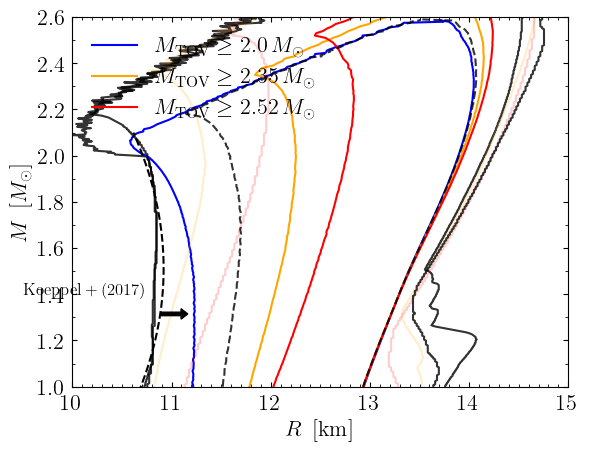

In [2]:
# importing libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
from scipy.optimize import curve_fit
from scipy import ndimage
from pylab import *
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.colors as mcolors

plt.rcParams.update({
    "text.usetex": True,
    'font.size': 16
    })

# MR-envlope
envel1=np.loadtxt("cloudMR2p0.txt")
envel2=np.loadtxt("cloudMR2p18.txt")
envel3=np.loadtxt("cloudMR2p35.txt")
envel4=np.loadtxt("cloudMR2p52.txt")

# 90% contours
cont1=np.loadtxt("cont0p1Mtov2p0.dat")
cont2=np.loadtxt("cont0p1Mtov2p18.dat")
cont3=np.loadtxt("cont0p1Mtov2p35.dat")
cont4=np.loadtxt("cont0p1Mtov2p52.dat")
# dirty trick to close the contour
cont4[-1,2]=cont4[-1,1]
cont3[-1,2]=cont3[-1,1]

# generating a figure
fig, ax0=plt.subplots(1,sharex=False,facecolor='white',dpi=100)
ax=[ax0]
plt.subplots_adjust(hspace=0)
ax[0].set_xlim([10,15])
ax[0].set_ylim([1,2.6])
ax[0].set_ylabel(r'$ M~\left[M_\odot\right]$',fontsize=16)
ax[0].set_xlabel(r'$R~\left[{\rm km}\right]$',fontsize=16)

# axis ticks
ticksx=[1,0.1]
ticksy=[0.20,0.10]
ax[0].yaxis.set_major_locator(MultipleLocator(ticksy[0]))
ax[0].yaxis.set_minor_locator(MultipleLocator(ticksy[1]))
ax[0].xaxis.set_major_locator(MultipleLocator(ticksx[0]))
ax[0].xaxis.set_minor_locator(MultipleLocator(ticksx[1]))
ax[0].tick_params(which='major',direction='in',pad=5,right=True,top=True,labelsize=16)
ax[0].tick_params(which='minor',direction='in',pad=5,right=True,top=True,labelsize=16)

# contours
# Mtov>2.0Msun
ax[0].plot(envel1[:,0],envel1[:,1], color = "black"  , linestyle = "solid",zorder=1, alpha=0.8)
ax[0].plot(envel1[:,2],envel1[:,3], color = "black"  , linestyle = "solid",zorder=1, alpha=0.8)
ax[0].plot( cont1[:,1], cont1[:,0], color = "blue"  , linestyle = "-",zorder=1)
ax[0].plot( cont1[:,2], cont1[:,0], color = "blue"  , linestyle = "-",zorder=1,label=r"$M_{\rm TOV}\geq 2.0\,M_\odot$")

# Mtov>2.35Msun
ax[0].plot(envel3[:,0],envel3[:,1], color = "orange", linestyle = "solid",zorder=1, alpha=0.2)
ax[0].plot(envel3[:,2],envel3[:,3], color = "orange", linestyle = "solid",zorder=1, alpha=0.2)
ax[0].plot( cont3[:,1], cont3[:,0], color = "orange", linestyle = "solid",zorder=1)
ax[0].plot( cont3[:,2], cont3[:,0], color = "orange", linestyle = "solid",zorder=1,label=r"$M_{\rm TOV}\geq 2.35\,M_\odot$")

# Mtov>2.52Msun
ax[0].plot(envel4[:,0],envel4[:,1], color = "red", linestyle = "solid",zorder=1, alpha=0.2)
ax[0].plot(envel4[:,2],envel4[:,3], color = "red", linestyle = "solid",zorder=1, alpha=0.2)
ax[0].plot( cont4[:,1], cont4[:,0], color = "red", linestyle = "solid",zorder=1)
ax[0].plot( cont4[:,2], cont4[:,0], color = "red", linestyle = "solid",zorder=1,label=r"$M_{\rm TOV}\geq 2.52\,M_\odot$")

#Koeppel+ prediction
Koeppel_mass = np.linspace(0.0,2.1,100) # computing the values of sin(x)/x
Koeppel_rad  = -0.88*Koeppel_mass**2 + 2.66 *Koeppel_mass + 8.91 # 
ax[0].plot(Koeppel_rad, Koeppel_mass, color="black",linestyle="--")
ax[0].text(9.5,1.40,r'${\rm Koeppel+ (2017)}$',fontsize=12)
ax[0].arrow(10.896, 1.315, 0.2, 0.0, width=0.015, color='k')

ax[0].legend(loc="upper left",fontsize=16,frameon=False)

# Mtov>2.18Msun
ax[0].plot(envel2[:,0],envel2[:,1], color = "black" , linestyle = "solid",zorder=1, alpha=0.8)
ax[0].plot(envel2[:,2],envel2[:,3], color = "black" , linestyle = "solid",zorder=1, alpha=0.8)
ax[0].plot( cont2[:,1], cont2[:,0], color = "black" , linestyle = "dashed",zorder=1, alpha=0.8)
ax[0].plot( cont2[:,2], cont2[:,0], color = "black" , linestyle = "dashed",zorder=1, alpha=0.8,label=r"$M_{\rm TOV}\geq 2.18\,M_\odot$")

# save the plot
plt.savefig("MR.pdf", dpi=100,bbox_inches='tight')
#plt.savefig("MRSFHo_large_v0.png", dpi=100,bbox_inches='tight')
#plt.savefig("MRBPS.png", dpi=100,bbox_inches='tight')
plt.show()